# Лабораторная работа №2: Вскрытие «Черного ящика» (Model-Agnostic методы)

## Задание 1: Иллюзия недвижимости (PDP vs ALE)

Обучили мощный Random Forest для оценки стоимости квартир. Показать график, как именно жилая площадь влияет на цену.


In [1]:
!pip install PyALE

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from PyALE import ale

In [3]:
df = pd.read_csv("Task2_1_housing.csv")
df.head()

,Area_sqm,Num_Rooms,Distance_to_metro,Floor,Price
0,105,4,27,13,17206.68
1,136,5,24,10,22516.23
2,95,3,22,3,14347.94
3,124,5,4,9,22178.72
4,136,5,2,12,24305.99


Обучим `RandomForestRegressor` для предсказания цены (Price).

In [4]:
X = df.drop(columns=["Price"])
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
print("R2:", model.score(X_test, y_test))

R2: 0.9970273141856382


Построим график Partial Dependence Plot (PDP) для признака `Area_sqm` и посмотрим, как этот признак влияет на предсказание цены.

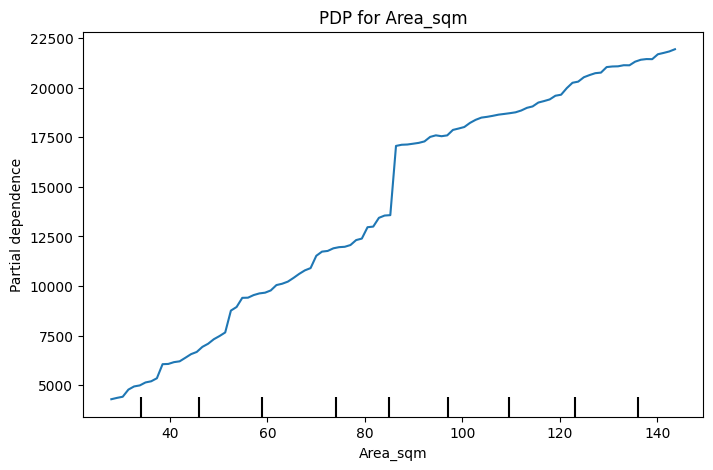

In [5]:
fig, ax = plt.subplots(figsize=(8,5))

PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    ["Area_sqm"],
    ax=ax
)

plt.title("PDP for Area_sqm")
plt.show()

**Как ведет себя цена при большой площади? Кажется ли этот тренд логичным?**
В целом цена квартиры растёт с увеличением площади, тренд логичен. Но заметен резкий скачок при большой площади (после 80). Это может быть реальной особенностью модели, а может быть из-за усреднения нереальных комбинаций. PDP усредняет предсказания по признаку без учёта распределения других признаков, из-за чего может возникнуть нереальная комбинация, примеров которой не было в обучающих данных. Он предсказывает цену для нее, усреднение для всех объектов даёт резкий скачок на графике, хотя реальных примеров такой комбинации почти нет.

Построим scatter-plot зависимости `Area_sqm` от `Num_Rooms`, чтобы понять почему PDP может ошибаться.


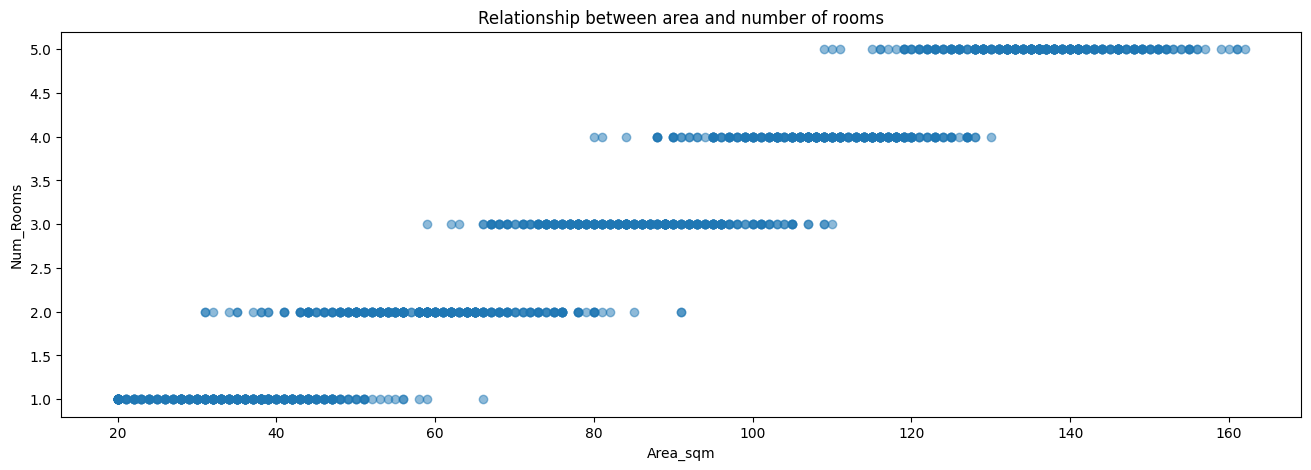

In [6]:
plt.figure(figsize=(16,5))

plt.scatter(df["Area_sqm"], df["Num_Rooms"], alpha=0.5)

plt.xlabel("Area_sqm")
plt.ylabel("Num_Rooms")
plt.title("Relationship between area and number of rooms")

plt.show()

**Какую фундаментальную ошибку совершил алгоритм PDP, учитывая распределение точек на этом графике?** График показывает, что количество комнат принимает только несколько дискретных значений, некоторые комбинации Area_sqm и Num_Rooms в данных просто отсутствуют. Фундаментальная ошибка PDP — игнорирование корреляции между признаками. Он строит график усреднённого влияния Area_sqm на цену, не учитывая реальные комбинации признаков. Усреднение по нереальным комбинациям создаёт искусственные скачки на графике.

График PDP не отражает поведение модели для реально встречающихся объектов, а лишь показывает гипотетическое среднее влияние признака.

Теперь построим ALE-plot для признака `Area_sqm`, который не создаёт искусственные комбинации признаков, а смотрит только области, где есть реальные точки.

INFO:PyALE._ALE_generic:Continuous feature detected.


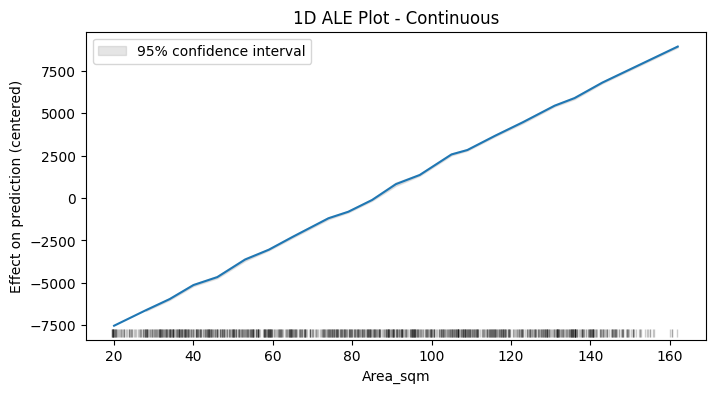

In [7]:
ale_eff = ale(
    X=X_train,
    model=model,
    feature=["Area_sqm"],
    grid_size=20 # признак разделим на 20 интервалов
)

График ровный и плавно возрастающий. ALE учитывает только реально существующие комбинации Area_sqm и Num_Rooms. 95% confidence interval показывает небольшую погрешность для оценки влияния признака.

PDP график неровный, имеет резкий скачок цены при больших значениях площади. Усредняет все объекты, создавая нереальные комбинации признаков (Area_sqm с несоответствующим числом комнат).Может вводить в заблуждение, показывая модель как слишком резко реагирующую на площадь.

**Какой график показывать бизнес-заказчику?** ALE, так как отражает поведение модели на реальных данных, не создавая нереалистичных скачков. PDP можно показывать только с оговоркой, что резкие изменения могут быть результатом усреднения нереальных комбинаций признаков.

## Задание 2: Медицинский консилиум (SHAP и UMAP)

Показать, как модель градиентного бустинга, предсказывающего риск развития сердечно-сосудистого заболевания, мыслит в целом, и объяснить диагнозы двух конкретных пациентов.

In [8]:
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import shap
import umap

In [9]:
df2 = pd.read_csv("Task2_2_medical.csv")
df2.head()

,Age,Cholesterol,Weight,Stress_Level,Risk
0,49,6.30,98.8,3,1
1,27,5.67,66.0,4,0
2,33,4.50,69.1,3,0
3,46,7.58,66.6,7,1
4,47,4.21,62.9,7,0


 Обучим модель градиентного бустинга `GradientBoostingClassifier`.

In [10]:
X = df2.drop(columns=["Risk"])
y = df2["Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GradientBoostingClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.95


Построим shap.summary_plot (beeswarm plot), который покажет, на сколько каждый признак увеличил или уменьшил предсказание модели, для всей тестовой выборки.

/tmp/ipykernel_426/4009337880.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


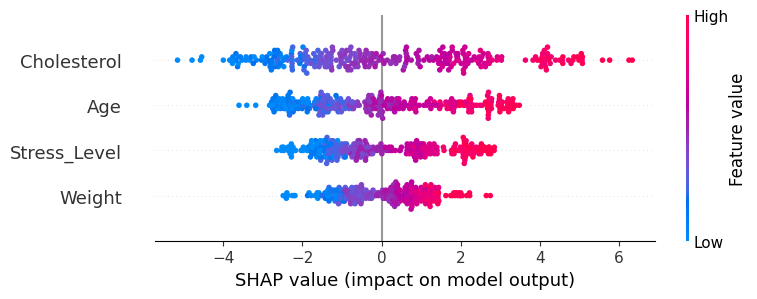

In [11]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

**Как возраст и уровень стресса влияют на риск заболевания? Какие закономерности (направление влияния, разброс) видно на графике?**
Для признака `Age` видно, что точки с высокими значениями возраста чаще расположены справа от нуля и увеличивает риск заболевания, а низкие слева снижают риск. Разброс значений SHAP достаточно заметный, возраст оказывает существенное влияние на предсказание модели.

Для признака `Stress_Level` наблюдается похожая закономерность. Высокие значения находятся справа от нуля и увеличивают риск заболевания, низкий уровень стресса уменьшает риск. Разброс значений примерно сопоставим с возрастом, стресс также является значимым фактором для модели.

Если рассматривать разброс точек, то видно, что вклад всех признаков распределён примерно симметрично относительно нулевой линии. Наибольший разброс у признака `Cholesterol`, он оказывает самое сильное влияние на предсказание. В целом график показывает, что большие значения всех показателей увеличивают предсказанный риск, а небольшие уменьшают, и модель использует эти признаки для разделения пациентов по уровню риска.

Теперь найдем в тестовой выборке пациентов с самым высоким и самым низким предсказанным риском с помощью метода predict_proba(), который возвращает вероятности принадлежности к каждому классу.

In [12]:
probs = model.predict_proba(X_test)[:,1] # только второй столбец, вероятность класса 1

highest_risk_index = np.argmax(probs)
lowest_risk_index = np.argmin(probs)

print("Predicted risk:", probs[highest_risk_index])
print("Predicted risk:", probs[lowest_risk_index])

Predicted risk: 0.9988202753780699
Predicted risk: 0.0010950858214671994


Построим для каждого из них shap.waterfall_plot, который покажет почему модель решила, что у этого пациента высокий или низкий риск.

Пациент с самым высоким предсказанным риском

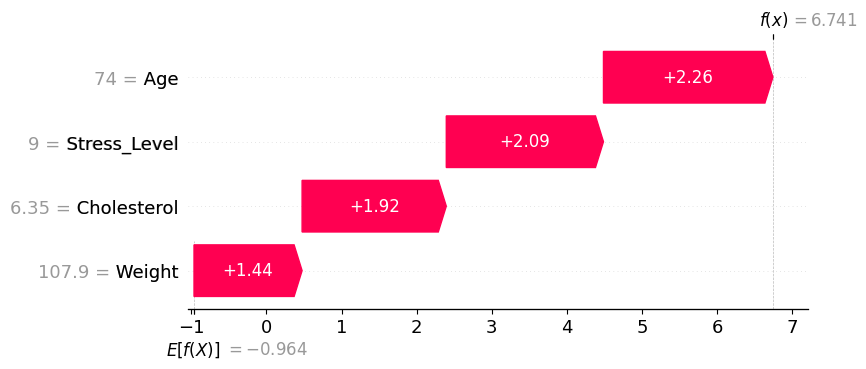

In [13]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[highest_risk_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[highest_risk_index],
        feature_names=X_test.columns
    )
)

Медицинское заключение: у пациента наблюдается высокий риск развития сердечно-сосудистого заболевания. Основными факторами являются пожилой возраст (74 года), высокий уровень стресса (9), повышенный уровень холестерина (6.35) и большая масса тела (107.9). Совокупность этих показателей значительно увеличивает вероятность развития осложнений.

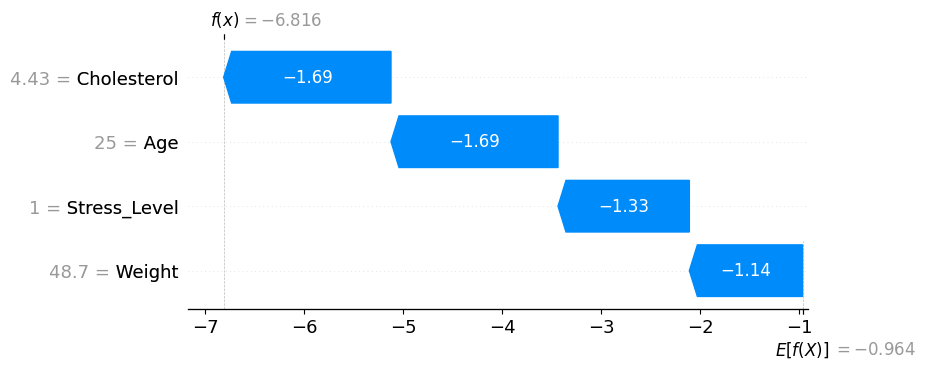

In [14]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[lowest_risk_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[lowest_risk_index],
        feature_names=X_test.columns
    )
)

Медицинское заключение: у пациента наблюдается низкий риск сердечно-сосудистого заболевания. Пациент молодого возраста (25 лет), имеет низкий уровень холестерина (4.43), небольшую массу тела (48.7) и низкий уровень стресса (1). Эти факторы указывают на благоприятное состояние и низкую вероятность развития заболевания.

Теперь визуализируем пространство признаков, чтобы понять, какие скрытые паттерны пациентов видит модель. Для этого применим к исходной матрице признаков UMAP, который ищет скрытую структуру данных и отображает объекты в 2D так, чтобы похожие пациенты находились рядом.

In [25]:
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)
print(embedding[:5])

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[[3.2361667  0.23555589]
 [2.2520647  8.764484  ]
 [2.3602362  8.005606  ]
 [5.2665377  7.5542855 ]
 [5.496469   7.7010465 ]]


Построем scatter-plot полученных 2D-точек, раскрасив их в цвета предсказанного моделью риска.

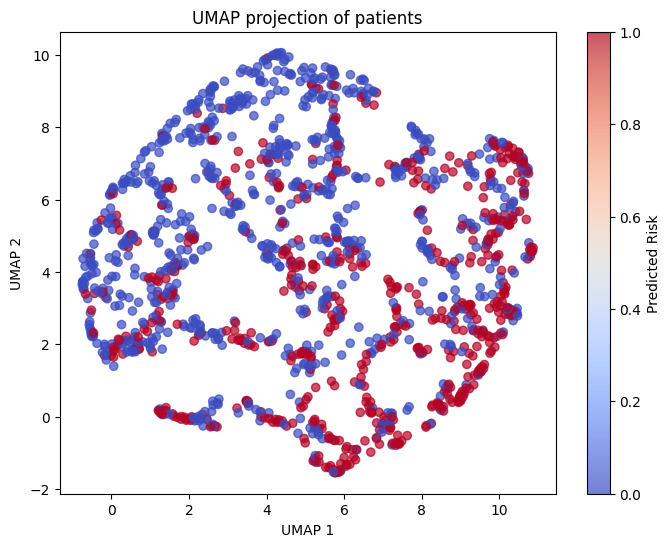

In [26]:
pred_risk = model.predict(X)

plt.figure(figsize=(8,6))
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=pred_risk,
    cmap="coolwarm",
    alpha=0.7
)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP projection of patients")
plt.colorbar(label="Predicted Risk")
plt.show()

**Видно ли вы четкие кластеры больных и здоровых людей?** На графике отдельные четкие кластеры больных и здоровых пациентов выделить сложно, в целом точки перемешаны. Некоторые пациенты могут быть похожи по 2D-координатам, но сильно отличаться по одному признаку, влияющему на риск. Но есть небольшая закономерность: более высокие предсказанные риски (красные точки) чаще расположены внизу справа, а низкие риски (синие точки) сверху слева. Это говорит о том, что модель видит некоторые скрытые паттерны в данных, но они не образуют полностью разделяемые группы на плоскости 2D и риск определяется по множеству факторов одновременно.